In [2]:
import pandas as pd

# This points to the cloud environment storage where your file now lives
df = pd.read_csv('/content/weather_data.csv')

# Look at the first 5 rows to confirm it loaded correctly!
df.head()

,Date,Temperature,Humidity,Precipitation,WindSpeed,Weather
0,2025-01-01,19.1,40,2.8,9.5,Sunny
1,2025-01-02,19.9,60,8.9,6.7,Sunny
2,2025-01-03,17.4,40,2.2,15.1,Sunny
3,2025-01-04,14.2,45,6.5,15.9,Sunny
4,2025-01-05,15.8,57,8.1,5.1,Sunny


In [3]:
# Display first 10 rows
df.head(10)

,Date,Temperature,Humidity,Precipitation,WindSpeed,Weather
0,2025-01-01,19.1,40,2.8,9.5,Sunny
1,2025-01-02,19.9,60,8.9,6.7,Sunny
2,2025-01-03,17.4,40,2.2,15.1,Sunny
3,2025-01-04,14.2,45,6.5,15.9,Sunny
4,2025-01-05,15.8,57,8.1,5.1,Sunny
5,2025-01-06,20.4,60,3.4,8.1,Sunny
6,2025-01-07,21.7,50,0.9,6.9,Sunny
7,2025-01-08,20.8,58,8.1,19.6,Sunny
8,2025-01-09,18.3,69,3.8,16.0,Sunny
9,2025-01-10,20.6,58,8.6,16.5,Sunny


In [4]:
# Display last 10 rows
df.tail(10)

,Date,Temperature,Humidity,Precipitation,WindSpeed,Weather
355,2025-12-22,18.2,55,9.9,16.1,Sunny
356,2025-12-23,17.1,54,6.4,24.6,Sunny
357,2025-12-24,16.0,40,7.9,11.9,Sunny
358,2025-12-25,19.9,58,7.7,19.7,Sunny
359,2025-12-26,16.7,41,5.5,21.3,Sunny
360,2025-12-27,15.4,63,4.6,18.9,Sunny
361,2025-12-28,19.1,64,0.6,20.5,Sunny
362,2025-12-29,17.7,48,0.4,9.0,Sunny
363,2025-12-30,14.3,68,5.2,24.8,Sunny
364,2025-12-31,18.3,47,7.5,8.8,Sunny


In [5]:
# Number of rows and columns
df.shape

(365, 6)

In [6]:
# Column names
df.columns

Index(['Date', 'Temperature', 'Humidity', 'Precipitation', 'WindSpeed',
       'Weather'],
      dtype='object')

In [7]:
# Information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           365 non-null    object 
 1   Temperature    365 non-null    float64
 2   Humidity       365 non-null    int64  
 3   Precipitation  365 non-null    float64
 4   WindSpeed      365 non-null    float64
 5   Weather        365 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 17.2+ KB


In [8]:
# Summary statistics
df.describe()

,Temperature,Humidity,Precipitation,WindSpeed
count,365.000000,365.000000,365.000000,365.000000
mean,25.950959,60.953425,8.615890,15.047397
std,5.947428,13.212778,5.696198,5.607601
min,14.000000,40.000000,0.000000,5.100000
25%,21.700000,49.000000,3.700000,10.100000
50%,26.600000,61.000000,8.000000,15.200000
75%,30.300000,69.000000,13.200000,19.900000
max,37.000000,89.000000,19.900000,25.000000


In [9]:
df.isnull().sum()

,0
Date,0
Temperature,0
Humidity,0
Precipitation,0
WindSpeed,0
Weather,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['Date'] = pd.to_datetime(df['Date'])

In [13]:
import numpy as np

In [14]:
print("Mean Temperature:", np.mean(df["Temperature"]))
print("Median Temperature:", np.median(df["Temperature"]))
print("Standard Deviation:", np.std(df["Temperature"]))

Mean Temperature: 25.95095890410959
Median Temperature: 26.6
Standard Deviation: 5.939275396139488


In [15]:
print("Mean Humidity:", np.mean(df["Humidity"]))
print("Median Humidity:", np.median(df["Humidity"]))
print("Standard Deviation:", np.std(df["Humidity"]))

Mean Humidity: 60.95342465753425
Median Humidity: 61.0
Standard Deviation: 13.194665611544991


In [16]:
print("Mean Precipitation:", np.mean(df["Precipitation"]))
print("Median Precipitation:", np.median(df["Precipitation"]))
print("Standard Deviation:", np.std(df["Precipitation"]))

Mean Precipitation: 8.615890410958905
Median Precipitation: 8.0
Standard Deviation: 5.688389481399794


In [17]:
df['Month'] = df['Date'].dt.month

In [18]:
monthly_analysis = df.groupby('Month')[['Temperature','Humidity','Precipitation']].mean()

monthly_analysis

,Temperature,Humidity,Precipitation
Month,,,
1,18.367742,53.677419,4.983871
2,17.475000,56.142857,4.885714
3,33.396774,53.903226,4.464516
4,33.300000,53.933333,3.610000
5,32.745161,54.193548,3.861290
6,27.043333,74.533333,15.586667
7,27.464516,77.064516,15.690323
8,26.790323,75.838710,15.358065
9,26.743333,72.300000,15.063333


In [19]:
def get_season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Summer"

    elif month in [6,7,8]:
        return "Monsoon"

    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

In [20]:
season_analysis = df.groupby('Season')[['Temperature','Humidity','Precipitation']].mean()

season_analysis

,Temperature,Humidity,Precipitation
Season,,,
Autumn,25.605495,59.395604,9.617582
Monsoon,27.100000,75.826087,15.544565
Summer,33.145652,54.010870,3.982609
Winter,17.771111,54.422222,5.256667


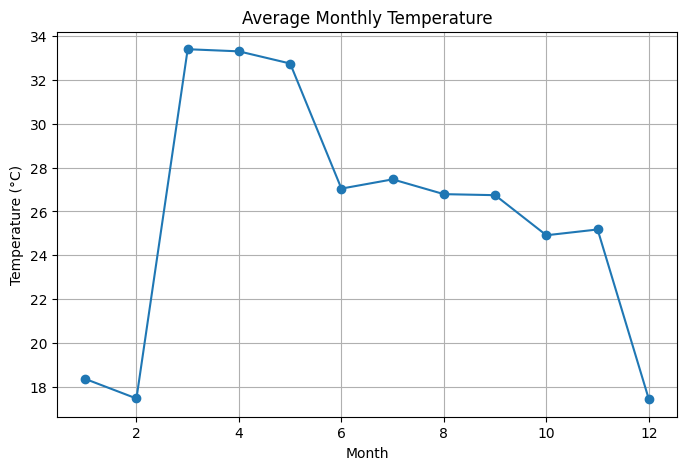

In [21]:
import matplotlib.pyplot as plt
monthly_analysis['Temperature'].plot(figsize=(8,5), marker='o')

plt.title("Average Monthly Temperature")

plt.xlabel("Month")

plt.ylabel("Temperature (°C)")

plt.grid(True)

plt.show()

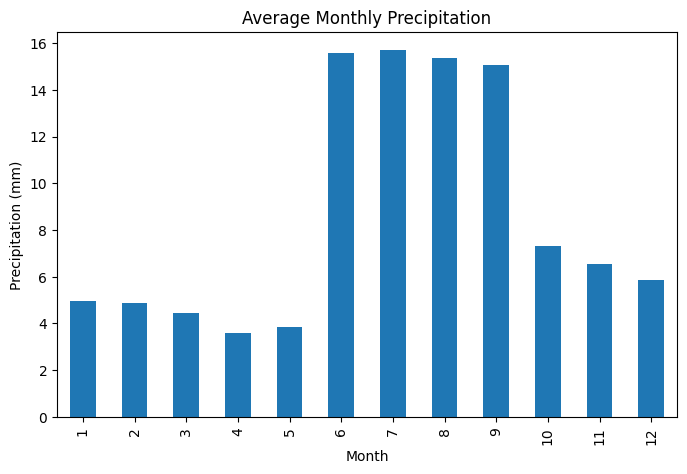

In [22]:
monthly_analysis['Precipitation'].plot(kind='bar', figsize=(8,5))

plt.title("Average Monthly Precipitation")

plt.xlabel("Month")

plt.ylabel("Precipitation (mm)")

plt.show()

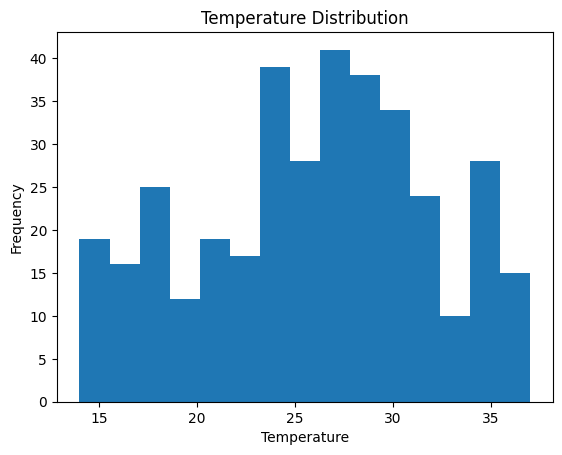

In [23]:
plt.hist(df["Temperature"], bins=15)

plt.title("Temperature Distribution")

plt.xlabel("Temperature")

plt.ylabel("Frequency")

plt.show()

In [24]:
hot_days = df[df['Temperature']>35]

hot_days

,Date,Temperature,Humidity,Precipitation,WindSpeed,Weather,Month,Season
59,2025-03-01,36.1,47,4.9,17.4,Sunny,3,Summer
65,2025-03-07,36.0,66,2.7,8.2,Sunny,3,Summer
66,2025-03-08,35.7,61,5.1,24.7,Sunny,3,Summer
75,2025-03-17,36.2,56,7.3,16.7,Sunny,3,Summer
77,2025-03-19,35.4,65,8.0,9.2,Sunny,3,Summer
80,2025-03-22,35.9,69,7.1,22.6,Sunny,3,Summer
82,2025-03-24,35.4,65,7.1,10.3,Sunny,3,Summer
83,2025-03-25,35.3,43,7.7,22.2,Sunny,3,Summer
85,2025-03-27,35.4,46,0.0,8.9,Sunny,3,Summer
88,2025-03-30,36.5,43,8.7,8.6,Sunny,3,Summer


In [25]:
heavy_rain = df[df['Precipitation']>15]

heavy_rain

,Date,Temperature,Humidity,Precipitation,WindSpeed,Weather,Month,Season
152,2025-06-02,23.7,66,16.9,11.1,Rainy,6,Monsoon
153,2025-06-03,27.7,74,15.3,13.5,Rainy,6,Monsoon
154,2025-06-04,29.0,69,17.0,10.4,Rainy,6,Monsoon
157,2025-06-07,26.9,81,19.8,15.5,Rainy,6,Monsoon
159,2025-06-09,24.4,60,15.3,10.5,Rainy,6,Monsoon
...,...,...,...,...,...,...,...,...
266,2025-09-24,23.5,68,16.3,16.0,Rainy,9,Autumn
267,2025-09-25,25.6,89,15.3,14.1,Rainy,9,Autumn
268,2025-09-26,27.8,62,17.0,22.1,Rainy,9,Autumn
269,2025-09-27,28.2,83,17.2,9.3,Rainy,9,Autumn


In [26]:
humid_days = df[df['Humidity']>90]

humid_days

,Date,Temperature,Humidity,Precipitation,WindSpeed,Weather,Month,Season


Conclusion

1. The dataset contains one year of weather observations.

2. No missing values or duplicate records were found.

3. Average temperature varies across different months.

4. Rainfall is highest during the monsoon season.

5. Temperature distribution shows that most days have moderate temperatures.

6. Extreme weather analysis identified hot days with temperatures above 35°C and heavy rainfall events with precipitation above 15 mm.

7. Pandas, NumPy, and Matplotlib were successfully used for data cleaning, analysis, and visualization.